# Chapter 19 Supplemental Notebook: Learning From Examples (Visualized)

This notebook is a **supplement** to `ch19_learning_from_examples.ipynb`.

Its goal is to make several of the most important ideas from **Chapter 19 – Learning From Examples** from *Artificial Intelligence: A Modern Approach* more concrete through **small runnable code examples** and **visualizations**.

## Notebook design

- Each section alternates between a **markdown explanation** and a **code example**
- Examples are aimed at a **first-time bachelor-level learner**
- The focus is on **intuition**, not mathematical completeness
- All examples are designed to run in **Python 3.12+**, including **Google Colab** and **Visual Studio Code**

## Topics covered

1. Entropy and information gain  
2. Decision tree training and visualization  
3. Learning curves  
4. Bias–variance tradeoff  
5. Linear regression and gradient descent  
6. Perceptron vs logistic regression  
7. k-nearest neighbors decision boundaries  
8. Support vector machines, margin, and the kernel trick  
9. Single decision tree vs random forest  
10. Gradient boosting progression  
11. ROC curve and confusion matrix  
12. Exploratory data analysis (EDA)

In [1]:

# Setup cell: imports and helper configuration

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_iris,
    load_wine,
    load_breast_cancer,
    make_classification,
    make_moons,
    make_regression,
)
from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    cross_val_score,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("Environment ready.")

Environment ready.


## 1. Entropy and Information Gain

### Core idea

- In decision tree learning, we want to choose the attribute that best **reduces uncertainty**
- **Entropy** measures uncertainty
- A split is useful if it creates child groups that are much “purer” than the original group
- **Information gain** tells us how much uncertainty is removed by a split

### Intuition

- A node with a 50/50 class split is highly uncertain
- A node with all examples in one class has entropy 0
- Decision trees prefer attributes that create purer branches

We will compute entropy and information gain on a tiny hand-made example similar in spirit to the restaurant problem.

Toy data:


,Patrons,Hungry,WillWait
0,Full,Yes,1
1,Full,No,0
2,Some,Yes,1
3,None,Yes,0
4,Full,Yes,1
5,Some,No,1
6,None,No,0
7,Full,No,0


Base entropy of target: 1.000
Information gain by feature:
  Patrons: 0.500
  Hungry: 0.189


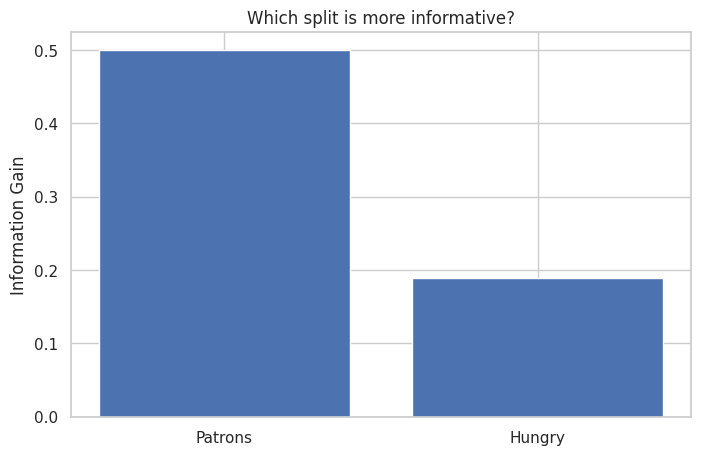

In [2]:

# Entropy and information gain on a tiny toy dataset

toy = pd.DataFrame({
    "Patrons": ["Full", "Full", "Some", "None", "Full", "Some", "None", "Full"],
    "Hungry":  ["Yes",  "No",   "Yes",  "Yes",  "Yes",  "No",   "No",   "No"],
    "WillWait":[1,      0,      1,      0,      1,      1,      0,      0]
})

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def information_gain(df, feature, target="WillWait"):
    total_entropy = entropy(df[target].values)
    weighted_entropy = 0.0

    for value, group in df.groupby(feature):
        weighted_entropy += len(group) / len(df) * entropy(group[target].values)
    return total_entropy - weighted_entropy

base_entropy = entropy(toy["WillWait"].values)
gains = {
    feature: information_gain(toy, feature)
    for feature in ["Patrons", "Hungry"]
}

print("Toy data:")
display(toy)
print(f"Base entropy of target: {base_entropy:.3f}")
print("Information gain by feature:")
for feature, gain in gains.items():
    print(f"  {feature}: {gain:.3f}")

plt.figure()
plt.bar(list(gains.keys()), list(gains.values()))
plt.ylabel("Information Gain")
plt.title("Which split is more informative?")
plt.show()

## 2. Decision Tree Training and Visualization

### Core idea

- A decision tree recursively splits data into smaller and purer groups
- Each internal node asks a question
- Each leaf gives a prediction
- Trees are appealing because they are often **interpretable**

### What to look for

- Which feature is chosen near the root?
- Are leaves pure?
- Does the tree become too deep?

We will train a small decision tree on the Iris dataset and visualize it.

Training accuracy: 1.000


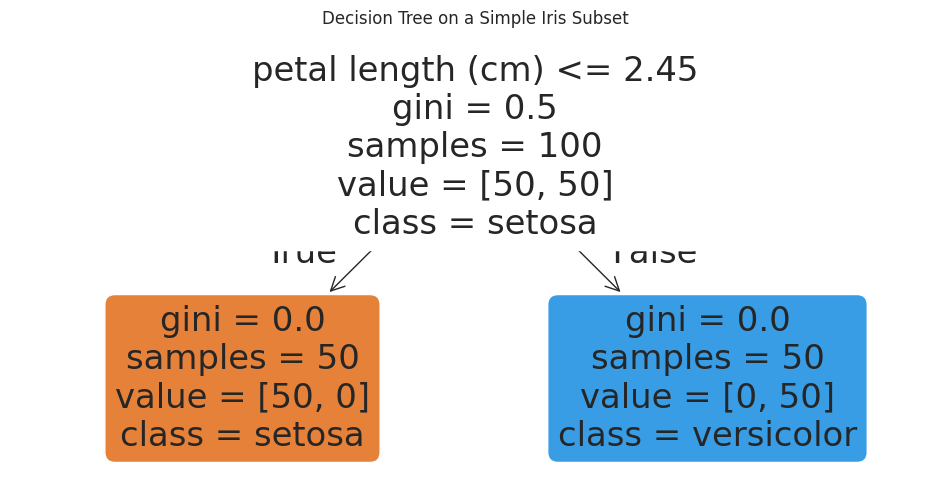

In [3]:

# Decision tree training and visualization on Iris

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# Use only 2 classes to keep the first example simpler
mask = y < 2
X_small = X.loc[mask, ["petal length (cm)", "petal width (cm)"]]
y_small = y.loc[mask]

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_small, y_small)

pred = tree.predict(X_small)
acc = accuracy_score(y_small, pred)

print(f"Training accuracy: {acc:.3f}")

plt.figure(figsize=(12, 6))
plot_tree(
    tree,
    feature_names=X_small.columns,
    class_names=["setosa", "versicolor"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree on a Simple Iris Subset")
plt.show()

## 3. Learning Curves

### Core idea

- A learning curve shows how performance changes as we increase training set size
- It helps answer a practical question: **Would more data help?**
- We often plot:
  - training performance
  - validation or test performance

### Typical patterns

- If both scores are low: the model may be **underfitting**
- If training is high but validation is low: the model may be **overfitting**
- If validation improves steadily: more data may still help

We will build a learning curve for a decision tree classifier.

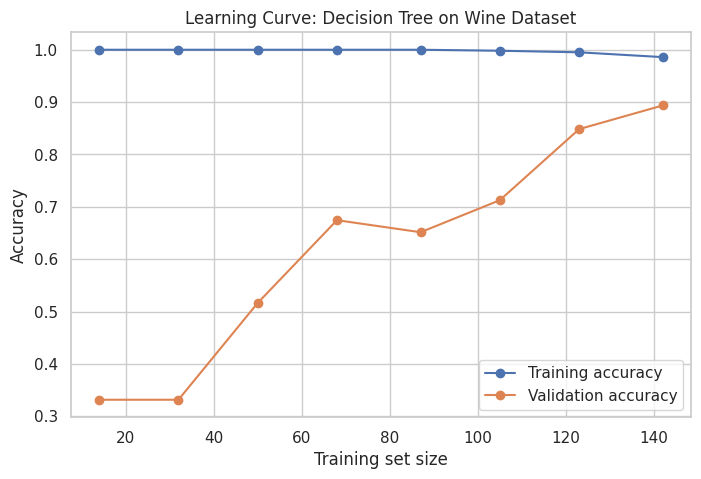

,train_size,train_accuracy,validation_accuracy
0,14,1.000000,0.331429
1,32,1.000000,0.331429
2,50,1.000000,0.516349
3,68,1.000000,0.674444
4,87,1.000000,0.651429
5,105,0.998095,0.712698
6,123,0.995122,0.848413
7,142,0.985915,0.893651


In [4]:

# Learning curve for a decision tree on the Wine dataset

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

model = DecisionTreeClassifier(max_depth=4, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy",
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Decision Tree on Wine Dataset")
plt.legend()
plt.show()

pd.DataFrame({
    "train_size": train_sizes,
    "train_accuracy": train_mean,
    "validation_accuracy": val_mean
})

## 4. Bias–Variance Tradeoff with Polynomial Fits

### Core idea

- A model that is too simple may **underfit**
- A model that is too flexible may **overfit**
- The challenge is to find a model with enough capacity to capture the pattern without chasing noise

### Classic illustration

- Degree 1 polynomial: often too rigid
- Medium degree: often a better compromise
- Very high degree: can wiggle too much

We will fit several polynomial models to noisy data and compare them visually.

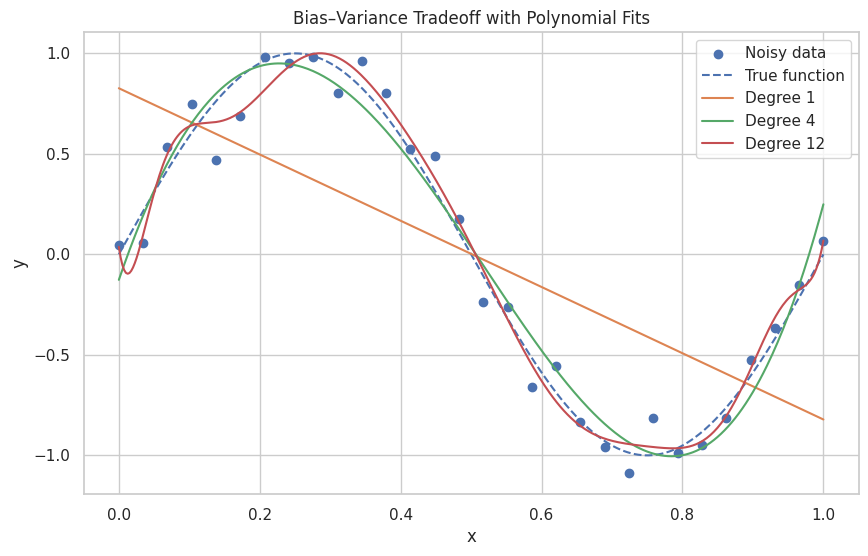

In [5]:

# Bias-variance tradeoff with polynomial regression

rng = np.random.default_rng(42)
X = np.linspace(0, 1, 30)
y_true = np.sin(2 * np.pi * X)
y = y_true + rng.normal(0, 0.15, size=X.shape)

X_plot = np.linspace(0, 1, 400)

degrees = [1, 4, 12]

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Noisy data")
plt.plot(X_plot, np.sin(2 * np.pi * X_plot), linestyle="--", label="True function")

for degree in degrees:
    coeffs = np.polyfit(X, y, degree)
    y_fit = np.polyval(coeffs, X_plot)
    plt.plot(X_plot, y_fit, label=f"Degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Bias–Variance Tradeoff with Polynomial Fits")
plt.legend()
plt.show()

## 5. Linear Regression and Gradient Descent

### Core idea

- Linear regression fits a line to data
- The usual objective is to minimize **squared error**
- For a simple line, there is a closed-form solution
- But gradient descent is important because it generalizes to more complex models

### What we will do

- Create synthetic linear data
- Fit the exact regression line
- Implement a simple gradient descent version
- Compare the two results

Gradient descent parameters: w=3.114, b=4.536
sklearn parameters:        w=3.061, b=4.889


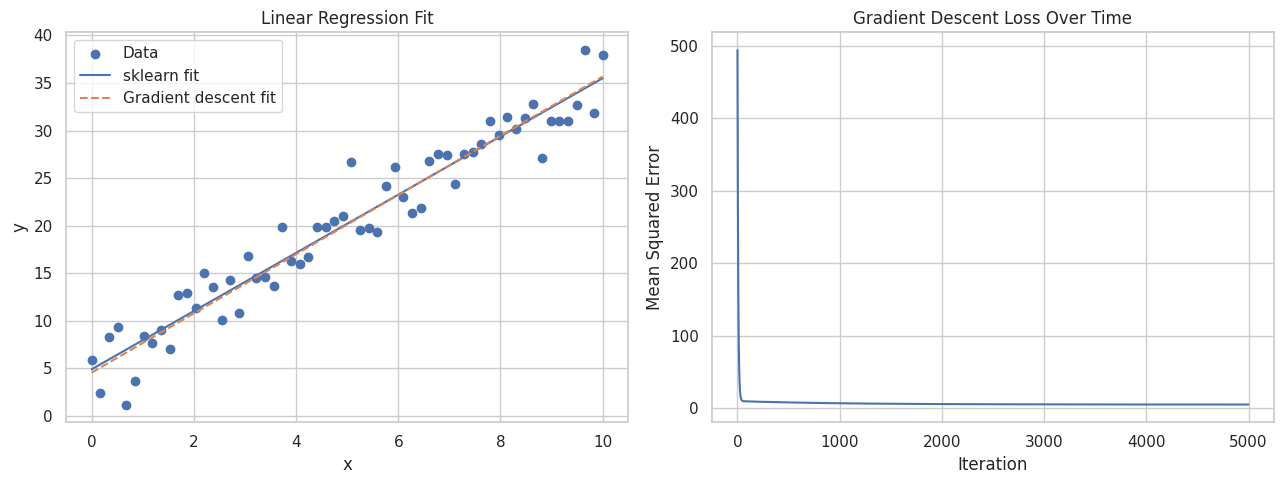

In [6]:

# Linear regression and plain-Python gradient descent

rng = np.random.default_rng(42)
X = np.linspace(0, 10, 60)
y = 3.0 * X + 5.0 + rng.normal(0, 3.0, size=X.shape)

# Closed-form / sklearn solution
lin_reg = LinearRegression()
lin_reg.fit(X.reshape(-1, 1), y)

# Plain gradient descent
w = 0.0
b = 0.0
lr = 0.001
epochs = 5000
n = len(X)

loss_history = []

for _ in range(epochs):
    y_pred = w * X + b
    error = y_pred - y
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    dw = (2 / n) * np.sum(error * X)
    db = (2 / n) * np.sum(error)

    w -= lr * dw
    b -= lr * db

print(f"Gradient descent parameters: w={w:.3f}, b={b:.3f}")
print(f"sklearn parameters:        w={lin_reg.coef_[0]:.3f}, b={lin_reg.intercept_:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X, y, label="Data")
axes[0].plot(X, lin_reg.predict(X.reshape(-1, 1)), label="sklearn fit")
axes[0].plot(X, w * X + b, linestyle="--", label="Gradient descent fit")
axes[0].set_title("Linear Regression Fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(loss_history)
axes[1].set_title("Gradient Descent Loss Over Time")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean Squared Error")

plt.tight_layout()
plt.show()

## 6. Perceptron vs Logistic Regression on 2D Data

### Core idea

- The **perceptron** uses a hard threshold
- **Logistic regression** uses a soft threshold and gives probabilities
- Logistic regression is often more stable and informative

### What to compare

- Both are linear classifiers
- Perceptron gives a hard decision
- Logistic regression lets us talk about uncertainty

We will train both on a simple 2D dataset and visualize their decision boundaries.

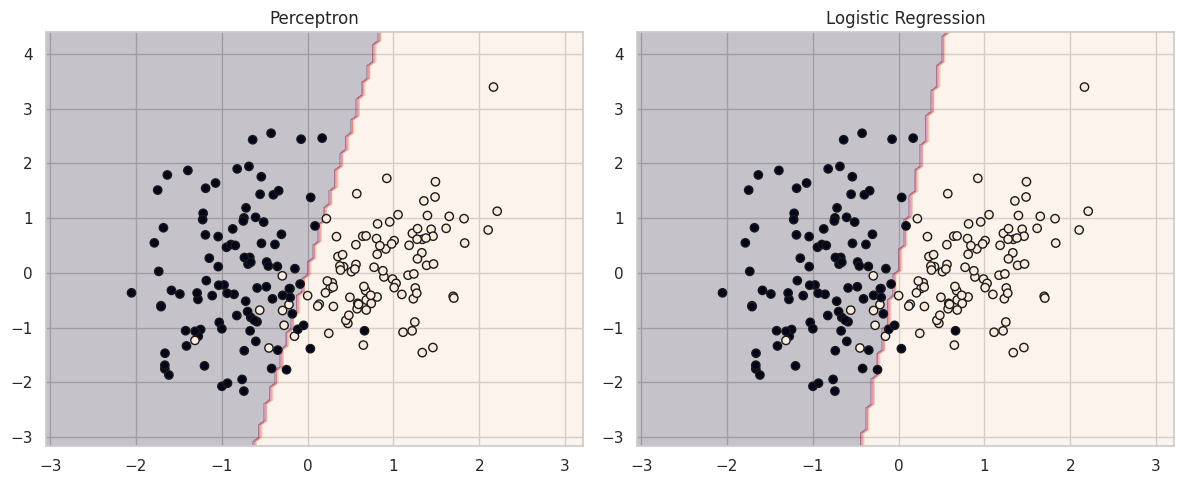

In [7]:

# Perceptron vs logistic regression

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

perceptron = Perceptron(random_state=42)
log_reg = LogisticRegression(random_state=42)

perceptron.fit(X_scaled, y)
log_reg.fit(X_scaled, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in [
    (axes[0], perceptron, "Perceptron"),
    (axes[1], log_reg, "Logistic Regression"),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_scaled,
        response_method="predict",
        alpha=0.25,
        ax=ax
    )
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolor="k")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. k-Nearest Neighbors Decision Boundaries

### Core idea

- k-nearest neighbors classifies a point based on nearby training examples
- Small **k**:
  - flexible
  - can overfit
- Larger **k**:
  - smoother
  - can underfit

### Why visualization helps

k-NN is one of the easiest algorithms to understand visually because its decision boundary changes strongly with the choice of **k**.

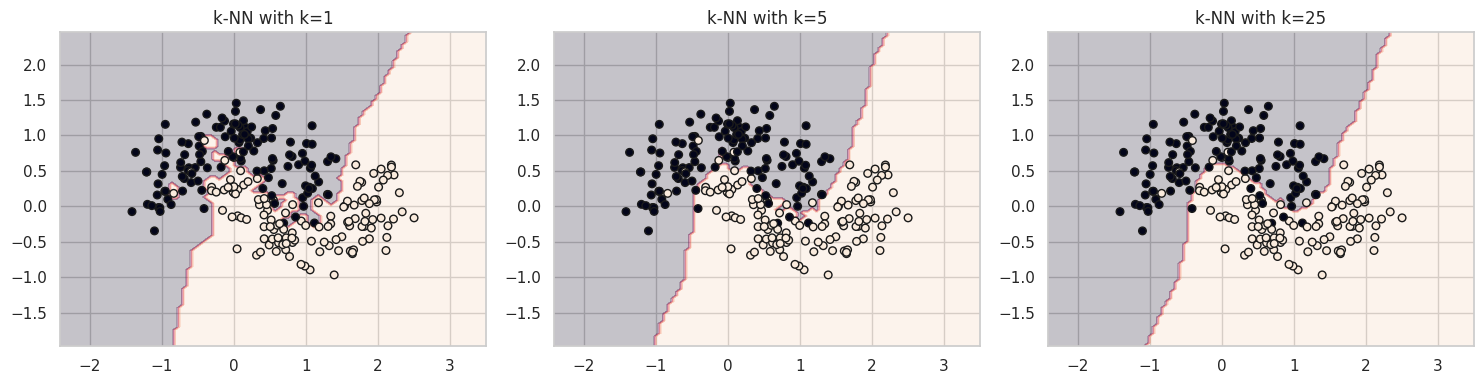

In [8]:

# k-NN decision boundaries for different k

X, y = make_moons(n_samples=250, noise=0.25, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 25]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    DecisionBoundaryDisplay.from_estimator(
        knn,
        X,
        response_method="predict",
        alpha=0.25,
        ax=ax
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=30)
    ax.set_title(f"k-NN with k={k}")

plt.tight_layout()
plt.show()

## 8. Support Vector Machines, Margin, and the Kernel Trick

### Core idea

- A support vector machine tries to find a separator with **maximum margin**
- The margin is the distance from the boundary to the nearest important points
- With kernels, SVMs can produce **nonlinear boundaries**

### What we will show

- Linear SVM on linearly separable-ish data
- Kernel SVM on nonlinear “moons” data

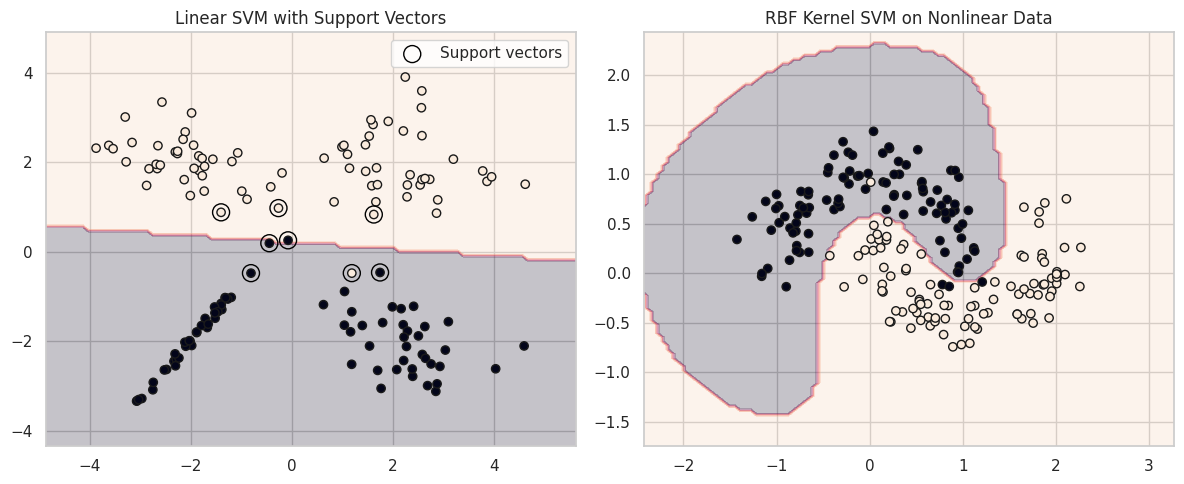

In [9]:

# Linear SVM and kernel SVM

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear SVM example
X1, y1 = make_classification(
    n_samples=150,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    class_sep=2.0,
    random_state=42
)
svm_linear = SVC(kernel="linear", C=1.0)
svm_linear.fit(X1, y1)

DecisionBoundaryDisplay.from_estimator(
    svm_linear, X1, response_method="predict", alpha=0.25, ax=axes[0]
)
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, edgecolor="k")
axes[0].scatter(
    svm_linear.support_vectors_[:, 0],
    svm_linear.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    label="Support vectors"
)
axes[0].set_title("Linear SVM with Support Vectors")
axes[0].legend()

# Kernel trick example
X2, y2 = make_moons(n_samples=200, noise=0.18, random_state=42)
svm_rbf = SVC(kernel="rbf", gamma=1.5, C=1.0)
svm_rbf.fit(X2, y2)

DecisionBoundaryDisplay.from_estimator(
    svm_rbf, X2, response_method="predict", alpha=0.25, ax=axes[1]
)
axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, edgecolor="k")
axes[1].set_title("RBF Kernel SVM on Nonlinear Data")

plt.tight_layout()
plt.show()

## 9. Single Decision Tree vs Random Forest

### Core idea

- A single decision tree is easy to interpret but can be unstable
- A random forest averages many trees
- This often reduces variance and improves generalization

### What to compare

- test accuracy
- decision boundaries
- stability of predictions

Decision Tree test accuracy: 0.856
Random Forest test accuracy: 0.878


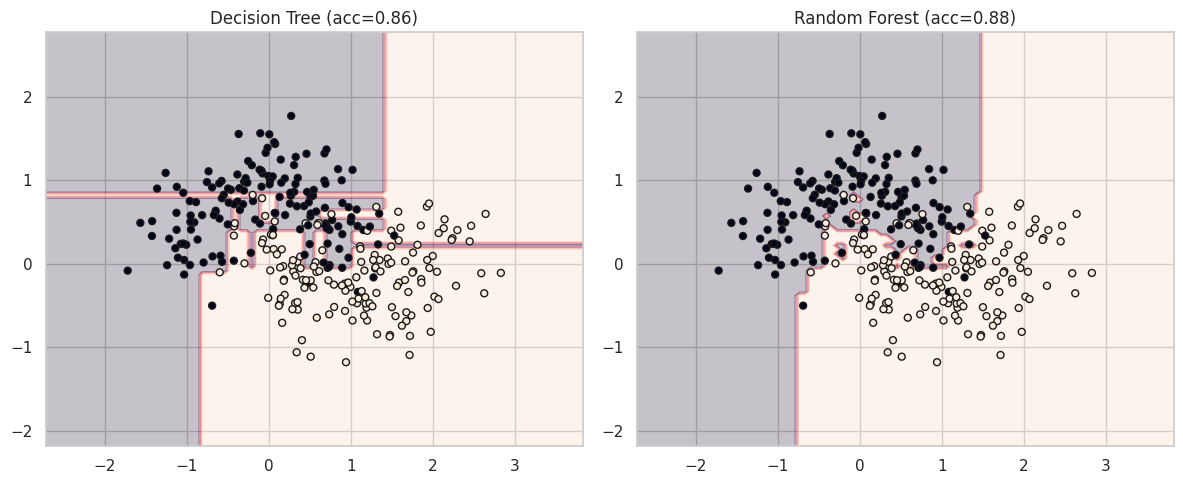

In [10]:

# Single tree vs random forest

X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

tree = DecisionTreeClassifier(random_state=42)
forest = RandomForestClassifier(n_estimators=200, random_state=42)

tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

tree_acc = accuracy_score(y_test, tree.predict(X_test))
forest_acc = accuracy_score(y_test, forest.predict(X_test))

print(f"Decision Tree test accuracy: {tree_acc:.3f}")
print(f"Random Forest test accuracy: {forest_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in [
    (axes[0], tree, f"Decision Tree (acc={tree_acc:.2f})"),
    (axes[1], forest, f"Random Forest (acc={forest_acc:.2f})"),
]:
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method="predict", alpha=0.25, ax=ax
    )
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=25)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 10. Gradient Boosting Progression

### Core idea

- Boosting builds a model **sequentially**
- Each new stage tries to improve on the previous ones
- Gradient boosting is one of the strongest general-purpose methods for tabular data

### What we will do

- Train gradient boosting models with increasing numbers of stages
- Plot test accuracy as the ensemble grows
- This shows how performance often improves gradually

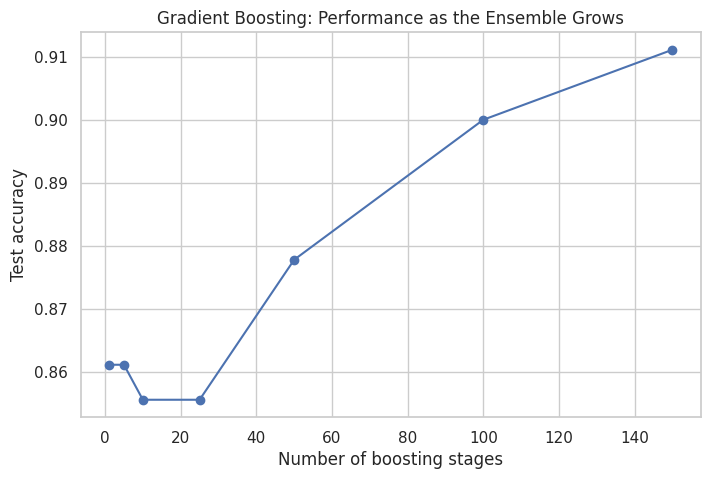

In [11]:

# Gradient boosting progression

X, y = make_classification(
    n_samples=600,
    n_features=10,
    n_informative=6,
    n_redundant=0,
    class_sep=1.2,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

n_estimators_list = [1, 5, 10, 25, 50, 100, 150]
scores = []

for n_estimators in n_estimators_list:
    gb = GradientBoostingClassifier(n_estimators=n_estimators, random_state=42)
    gb.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, gb.predict(X_test)))

pd.DataFrame({
    "n_estimators": n_estimators_list,
    "test_accuracy": scores
})

plt.figure()
plt.plot(n_estimators_list, scores, marker="o")
plt.xlabel("Number of boosting stages")
plt.ylabel("Test accuracy")
plt.title("Gradient Boosting: Performance as the Ensemble Grows")
plt.show()

## 11. ROC Curve and Confusion Matrix

### Core idea

- Accuracy alone can be misleading
- For classification, we often want richer evaluation tools:
  - **confusion matrix**
  - **ROC curve**
  - **AUC**

### Why they matter

- The confusion matrix shows *what type* of mistakes are made
- The ROC curve shows the tradeoff between:
  - true positive rate
  - false positive rate

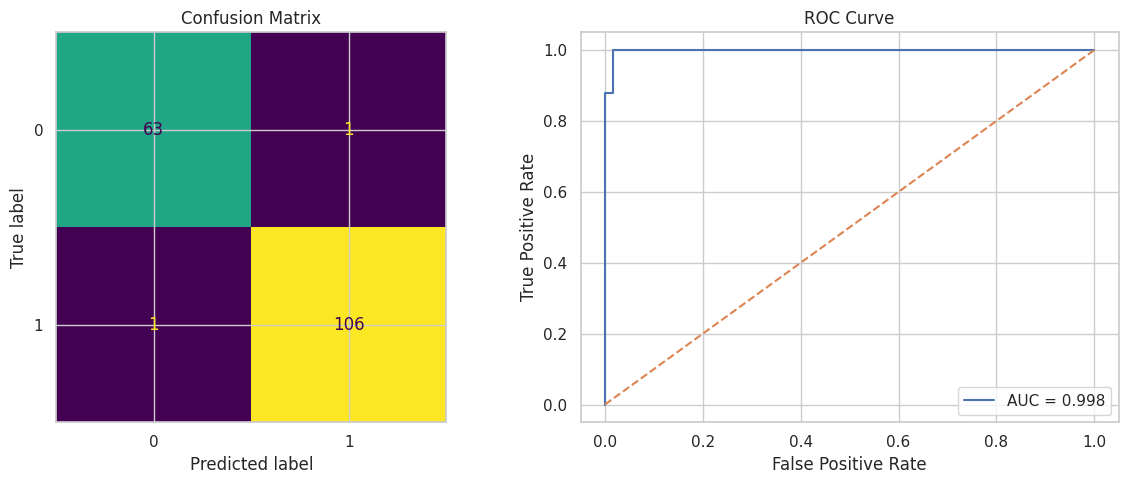

In [12]:

# ROC curve and confusion matrix with breast cancer dataset

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_score = pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Exploratory Data Analysis (EDA)

### Core idea

Before training models, we should understand the data.

### Typical EDA questions

- What do the feature distributions look like?
- Are there outliers?
- Which classes are present?
- Which features appear related?
- Do some classes separate visually?

### What we will do

We will perform a mini EDA workflow on the Iris dataset using:

- a data preview
- summary statistics
- histograms
- pair plots
- a correlation heatmap

First rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Summary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


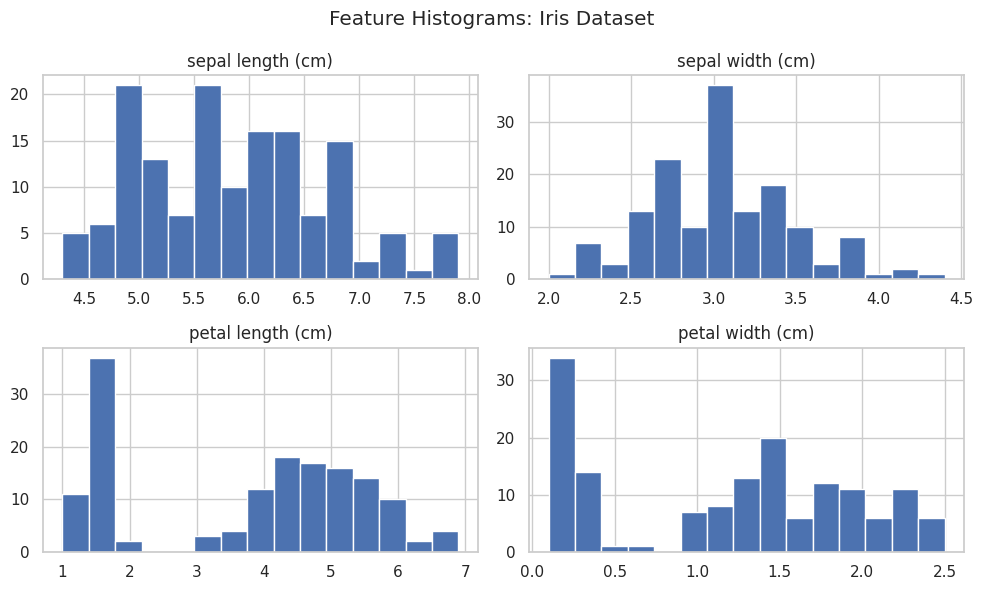

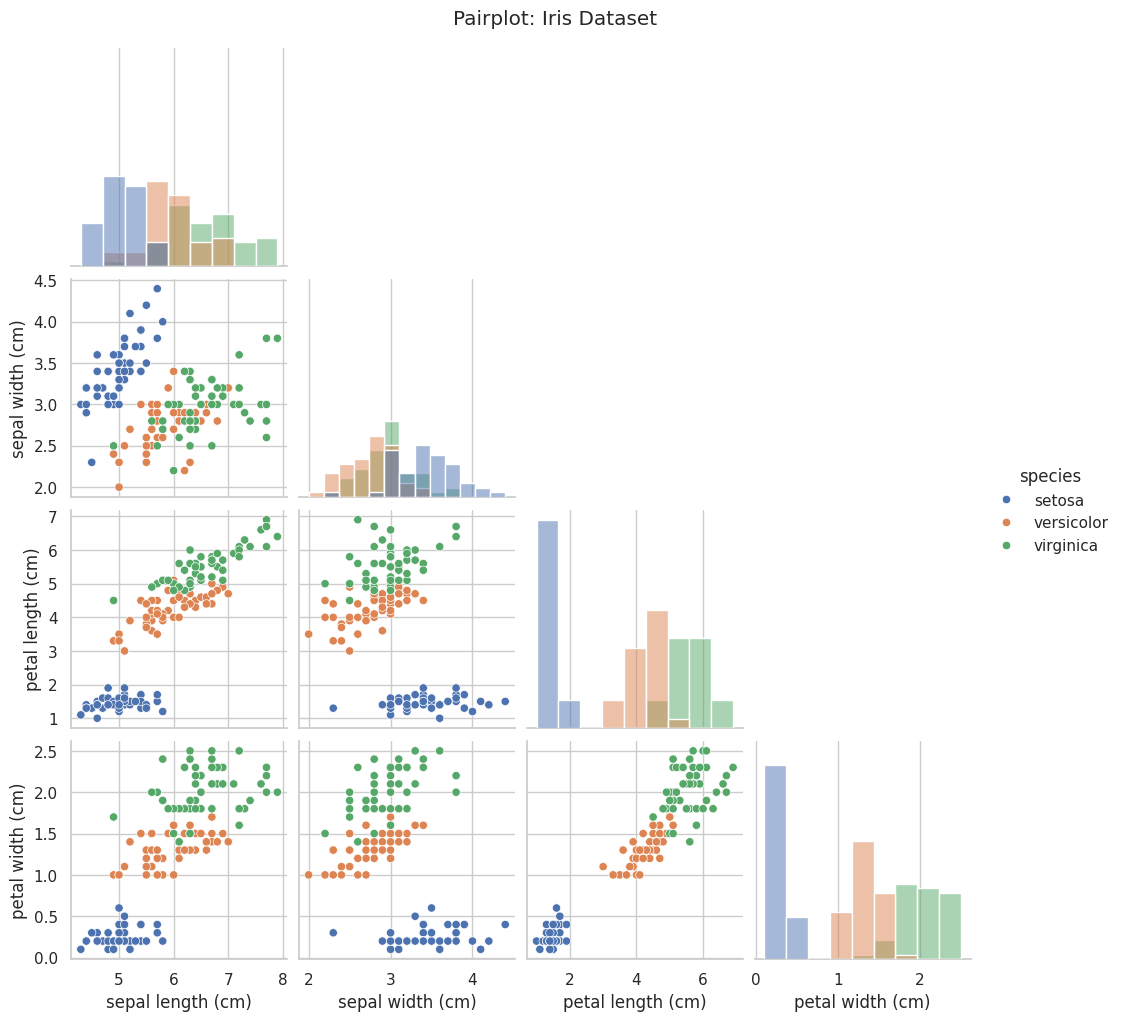

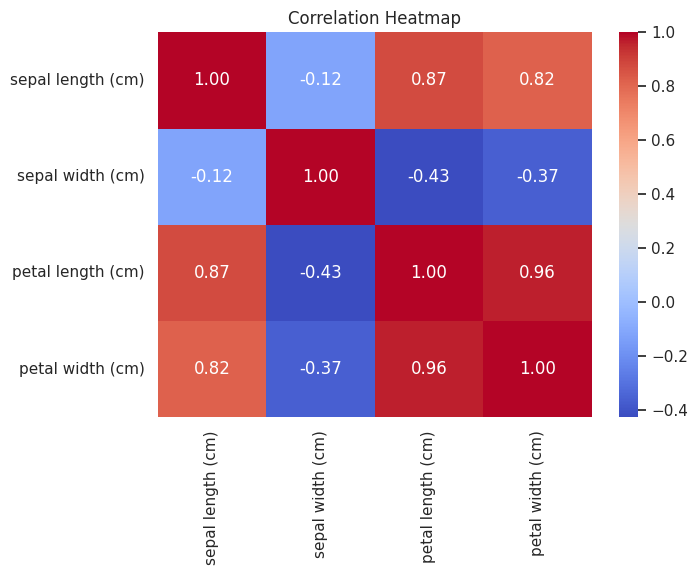

In [13]:

# Mini EDA workflow on Iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

print("First rows:")
display(df.head())

print("Summary statistics:")
display(df.describe())

# Histograms
df[iris.feature_names].hist(figsize=(10, 6), bins=15)
plt.suptitle("Feature Histograms: Iris Dataset")
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species",
    corner=True,
    diag_kind="hist"
)
plt.suptitle("Pairplot: Iris Dataset", y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[iris.feature_names].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Summary

This notebook added **visual and computational support** for some of the most important ideas in Chapter 19.

## What you should now be able to recognize

- how **entropy** and **information gain** guide decision trees
- what a **decision tree** looks like and how it partitions data
- how **learning curves** reveal underfitting, overfitting, and data hunger
- what the **bias–variance tradeoff** looks like in polynomial fitting
- how **linear regression** can be optimized by **gradient descent**
- the difference between a **perceptron** and **logistic regression**
- how the choice of **k** changes k-nearest-neighbor behavior
- why SVMs care about **margin**, and how the **kernel trick** enables nonlinear separation
- why **random forests** are often more stable than a single tree
- how **gradient boosting** improves stage by stage
- why **ROC curves** and **confusion matrices** matter in model evaluation
- how **EDA** helps us understand data before modeling

## Suggested next steps

- Re-run cells and change hyperparameters
- Try different datasets from `scikit-learn`
- Compare models on the same problem
- Add markdown notes with your own interpretations after each plot

This notebook is meant to be a **supplementary bridge** between textbook ideas and hands-on experimentation.